In [18]:
import torch
from torch import nn
import torch_geometric
from torch_geometric.nn import GATConv, SAGEConv, GraphConv, GraphSAGE
import torch
import networkx as nx 
from torch.utils.data import Dataset
import pickle
import pdb 
import numpy as np
from torch_geometric.data import Data
import networkx as nx
import numpy as np
import pandas as pd 
import pickle
import pdb
from torch_geometric.loader import DataLoader
import torch.optim as optim
import torch.nn.functional as F
from torch_geometric.utils import to_dense_adj, subgraph, k_hop_subgraph
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.join(os.path.dirname(sys.path[0]),'tools'))
from sklearn.neighbors import kneighbors_graph
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch_geometric.data import Data
# from newGraphDat import GraphDataset
from GraphDatAll import GraphDataset

# from graphDat import GraphDataset
# from ClassGraphDat import GraphDataset

torch.manual_seed(42)

In [19]:

# class GraphEncoderWithResidual(nn.Module):
#     def __init__(self, in_channels, hidden_channels, out_channels):
#         super(GraphEncoderWithResidual, self).__init__()
#         self.conv1 = SAGEConv(in_channels, hidden_channels*2)
#         self.conv2 = SAGEConv(hidden_channels*2, hidden_channels)
#         # self.conv3 = SAGEConv(hidden_channels, out_channels)
#         self.lin = nn.Linear(hidden_channels, out_channels)
#         # Linear transformation to match dimensions for residual connection
#         self.shortcut = nn.Linear(in_channels, out_channels)
#         # self.sm = nn.Softmax(dim=1)

#     def forward(self, x, edge_index):
#         identity = x
#         x = F.relu(self.conv1(x, edge_index))
#         x = F.relu(self.conv2(x, edge_index))
#         # x = self.conv3(x, edge_index)
#         x = self.lin(x)
#         # Applying shortcut and adding it to the output of conv3
#         identity = self.shortcut(identity)
#         x += identity  # Element-wise addition
#         # print('before: ', x[0])
#         # print(np.shape(x))
#         # x = self.sm(x)
#         # print('after: ', x[0])
#         return x
    
# class GraphEncoderWithResidual(nn.Module):
#     def __init__(self, in_channels, hidden_channels, out_channels):
#         super(GraphEncoderWithResidual, self).__init__()
#         self.conv1 = SAGEConv(in_channels, hidden_channels*4)
#         self.conv2 = SAGEConv(hidden_channels*4, hidden_channels*2)
#         self.conv3 = SAGEConv(hidden_channels*2, hidden_channels)
#         self.lin1 = nn.Linear(hidden_channels, int(hidden_channels/2))
#         self.lin2 = nn.Linear(int(hidden_channels/2), out_channels)
#         # Linear transformation to match dimensions for residual connection
#         self.shortcut = nn.Linear(in_channels, out_channels)
#         # self.sm = nn.Softmax(dim=1)

#     def forward(self, x, edge_index):
#         identity = x
#         x = F.relu(self.conv1(x, edge_index))
#         x = F.relu(self.conv2(x, edge_index))
#         x = self.conv3(x, edge_index)
#         x = F.relu(self.lin1(x))
#         x = F.dropout(x, p=0.2)
#         x = self.lin2(x)
#         # Applying shortcut and adding it to the output of conv3
#         identity = self.shortcut(identity)
#         x += identity  # Element-wise addition
#         # x = self.sm(x)
#         return x
    

class GraphEncoderWithResidual(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GraphEncoderWithResidual, self).__init__()
        self.conv1 = GATConv(in_channels, hidden_channels*4)#, flow="source_to_target", root_weight=False)
        self.conv2 = GATConv(hidden_channels*4, hidden_channels*2)#, flow="source_to_target", root_weight=False)
        self.conv3 = GATConv(hidden_channels*2, hidden_channels)#, flow="source_to_target", root_weight=False)
        # self.conv1 = SAGEConv(in_channels, hidden_channels*4, flow="target_to_source", root_weight=False)
        # self.conv2 = SAGEConv(hidden_channels*4, hidden_channels*2, flow="target_to_source", root_weight=False)
        # self.conv3 = SAGEConv(hidden_channels*2, hidden_channels, flow="target_to_source", root_weight=False)
        self.lin1 = nn.Linear(hidden_channels, out_channels)#int(hidden_channels/2))
        # self.lin2 = nn.Linear(int(hidden_channels/2), out_channels)
        # Linear transformation to match dimensions for residual connection
        self.shortcut = nn.Linear(in_channels, out_channels)
        # self.sm = nn.Softmax(dim=1)

    def forward(self, x, edge_index):
        identity = x
        x1 = F.relu(self.conv1(x, edge_index))
        x1 = F.relu(self.conv2(x1, edge_index))
        x1 = self.conv3(x1, edge_index)
        # x = F.dropout(F.relu(self.lin1(x)), p=0.5)
        x1 = self.lin1(x1)
        # Applying shortcut and adding it to the output of conv3
        identity = self.shortcut(identity)
        x1 += identity  # Element-wise addition
        # x = self.sm(x)
        return x1

In [20]:
# # Assuming a loss function appropriate for node feature reconstruction, e.g., MSE for continuous features
# def loss_function(reconstructed_x, original_x):
#     # print(/)
#     return F.cross_entropy(reconstructed_x, original_x)

def cosine_loss(adj, emb):
    norms = torch.norm(emb, p=2, dim=1, keepdim=True)
    normalized_embeddings = emb / norms.clamp(min=1e-4)
    cosine_similarity_matrix = torch.mm(normalized_embeddings, normalized_embeddings.t())
    target_adjacency = torch.zeros_like(cosine_similarity_matrix)
    target_adjacency[adj[0], adj[1]] = 1
    # Directly using logits; no need to apply sigmoid.
    return F.binary_cross_entropy_with_logits(cosine_similarity_matrix, target_adjacency)

In [21]:
def train(model, data_loader, optimizer, device):
    model.train()
    total_loss = 0
    embeddings = []
    # origs = []
    # lossfunc = nn.CrossEntropyLoss()
    # print(data_loader)
    for feat, edge in data_loader: #, _, glob 
        optimizer.zero_grad()
        # pdb.set_trace()
        # print(np.shape(feat), np.shape(edges))
        # print('in main: ', np.shape(feat), np.shape(edges))
        features = feat.squeeze_(0).to(device)
        # globalInfo = glob.squeeze_(0).to(device)
        edges = edge.squeeze_(0).to(device)
        # embed = model(torch.cat([globalInfo, features], dim=1), edges)
        # origs.append(data[0][0].detach())
        # print(np.shape(embed), np.shape(data[2][0]))
        # print()
        # print(data[2][0][0], embed[0].detach())
        # loss = lossfunc(embed, data[2][0].to(device))
        # print(np.shape(embed), np.shape(data[2][0]), np.shape(data[0][0]), np.shape(data[1][0]))
        # loss = loss_function(embed, data[2][0].to(device)) #cosine_loss(data[1][0].to(device), embed)
        embed = model(features, edges)
        loss = cosine_loss(edges, embed)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        embeddings.append(embed.detach())
        # print(total_loss)
    return total_loss / len(data_loader), embeddings#, origs

In [22]:
# data = torch.load('finished_graph.pth')
# print(data)


In [23]:
# np.shape(data['feat'][1])

In [24]:
folder_graph = './finished_some/'
device = "cpu"
# fname = 'small_graphs.pth'
files = os.listdir(folder_graph)
files = [file for file in files if file.endswith('.pickle')]
hC = 8
inC = 40


# data = torch.load('finished_graph.pth')

# Create a graph data object
# graph = Data(x=node_features, edge_index=adjacency_matrix.coalesce().indices(), edge_attr=edge_features)

dataset = GraphDataset(folder_graph, files)
# print('data loaded')
# print(dataset)
dataloader = DataLoader(dataset, batch_size=1, shuffle=True, num_workers=16)
actuals = []
final_loss = []
embeddings = []
outchannels = 3

# torch.save(decoder_state_dict, './CDC/decoder_state_dict'+str(outchannels)+'.pth')
        # print(np.shape(embed), np.shape(data[2][0]), np.shape(data[0][0]), np.shape(data[1][0]))


/Users/puneet/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 12 (`cpuset` is not taken into account), which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


In [25]:
# print(len(dataset))
# for feat, edges, _, _  in dataloader:
#     print(np.shape(feat), np.shape(edges))
    # break

In [26]:
model = GraphEncoderWithResidual(in_channels=inC, hidden_channels=hC, out_channels=outchannels).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.01)
# scheduler = ReduceLROnPlateau(optimizer, 'min', factor=0.1, patience=3, verbose=True)
# losses = []
embeds = []
# torch.autograd.set_detect_anomaly(True)
# acts = []
for epoch in range(1, 5):  # Number of epochs
    # loss, embed, orig = train(model, dataloader, optimizer, device)
    loss, _ = train(model, dataloader, optimizer, device)
    # embeds.append(embed)
    # acts.append(orig)
    print(f'Epoch {epoch}, Loss: {loss:.4f}')
    # losses.append(loss)
    # scheduler.step(loss)
# epoch_loss = loss / len(dataloader)
# embeddings.append(embeds)
# final_loss.append(losses)
# actuals.append(acts)
# model.eval()
# # Assuming encoder and decoder are your model's components
# encoder_state_dict = model.state_dict()
# # decoder_state_dict = model.decoder.state_dict()
# # Save the state dictionaries
# torch.save(encoder_state_dict, './Finished_Large_LinNew_encoder_state_dict'+str(outchannels)+'.pth')

Epoch 1, Loss: 0.9190
Epoch 2, Loss: 0.8575
Epoch 3, Loss: 0.8294
Epoch 4, Loss: 0.8138


In [27]:
optimizer = optim.Adam(model.parameters(), lr=0.01)
# scheduler = ReduceLROnPlateau(optimizer, 'min', factor=0.1, patience=3, verbose=True)
for epoch in range(1, 20):  # Number of epochs
    # loss, embed, orig = train(model, dataloader, optimizer, device)
    loss, _ = train(model, dataloader, optimizer, device)
    # embeds.append(embed)
    # acts.append(orig)
    print(f'Epoch {epoch}, Loss: {loss:.4f}')
    # losses.append(loss)
    # scheduler.step(loss)
# model.eval()
# encoder_state_dict = model.state_dict()
# # decoder_state_dict = model.decoder.state_dict()
# # Save the state dictionaries
# torch.save(encoder_state_dict, './Finished_Large_LinNew_encoder_state_dict'+str(outchannels)+'.pth')

Epoch 1, Loss: 0.8063
Epoch 2, Loss: 0.7976
Epoch 3, Loss: 0.7978
Epoch 4, Loss: 0.8042
Epoch 5, Loss: 0.8083
Epoch 6, Loss: 0.8007
Epoch 7, Loss: 0.7940
Epoch 8, Loss: 0.7962
Epoch 9, Loss: 0.7947
Epoch 10, Loss: 0.8193
Epoch 11, Loss: 0.7929
Epoch 12, Loss: 0.7857
Epoch 13, Loss: 0.7904
Epoch 14, Loss: 0.7811
Epoch 15, Loss: 0.7758
Epoch 16, Loss: 0.7886
Epoch 17, Loss: 0.7903
Epoch 18, Loss: 0.8002
Epoch 19, Loss: 0.7767


In [28]:
optimizer = optim.Adam(model.parameters(), lr=0.001)
# scheduler = ReduceLROnPlateau(optimizer, 'min', factor=0.1, patience=3, verbose=True)
for epoch in range(1, 10):  # Number of epochs
    # loss, embed, orig = train(model, dataloader, optimizer, device)
    loss, embed = train(model, dataloader, optimizer, device)
    embeds.append(embed)
    # acts.append(orig)
    print(f'Epoch {epoch}, Loss: {loss:.4f}')
    # losses.append(loss)
    # scheduler.step(loss)
model.eval()
encoder_state_dict = model.state_dict()
# decoder_state_dict = model.decoder.state_dict()
# Save the state dictionaries
torch.save(encoder_state_dict, './Finished_Large_LinNew_encoder_state_dict'+str(outchannels)+'.pth')

Epoch 1, Loss: 0.7671
Epoch 2, Loss: 0.7612
Epoch 3, Loss: 0.7565
Epoch 4, Loss: 0.7554
Epoch 5, Loss: 0.7539
Epoch 6, Loss: 0.7535
Epoch 7, Loss: 0.7560
Epoch 8, Loss: 0.7543
Epoch 9, Loss: 0.7527


In [29]:
# for i in embeddings:
#     df = pd.DataFrame(emb, columns=['x', 'y', 'z'])
#     df.to_csv('./RS/LinNew_ALLENVS_AGENTS_emb.csv')

#     df = pd.DataFrame(arrpos, columns=['pose1', 'pose2', 'pose3', 'pose4'])
#     df.to_csv('./RS/LinNew_ALLENVS_AGENTS_poses.csv')

#     df = pd.DataFrame(arrqual, columns=['qual1', 'qual2', 'qual3', 'qual4'])
#     df.to_csv('./RS/LinNew_ALLENVS_AGENTS_quals.csv')


#     df = pd.DataFrame(arr_global_info, columns=['1', '2', '3', '4'])
#     df.to_csv('./RS/LinNew_ALLENVS_AGENTS_global_info.csv')

#     df = pd.DataFrame(arrcol, columns=['colors'])
#     df.to_csv('./RS/LinNew_ALLENVS_AGENTS_colors.csv')

#     df = pd.DataFrame(arr_num_agents, columns=['num_agents'])
#     df.to_csv('./RS/LinNew_ALLENVS_AGENTS_num_agents.csv')
# optimizer = optim.Adam(model.parameters(), lr=0.0001)
# # scheduler = ReduceLROnPlateau(optimizer, 'min', factor=0.1, patience=3, verbose=True)
# for epoch in range(1, 5):  # Number of epochs
#     loss, embed, orig = train(model, dataloader, optimizer, device)
#     # embeds.append(embed)
#     # acts.append(orig)
#     print(f'Epoch {epoch}, Loss: {loss:.4f}')
#     # losses.append(loss)
#     # scheduler.step(loss)
# encoder_state_dict = model.state_dict()
# # decoder_state_dict = model.decoder.state_dict()
# # Save the state dictionaries
# torch.save(encoder_state_dict, './LinNew_encoder_state_dict'+str(outchannels)+'.pth')

In [30]:


# sf = nn.Softmax(dim=1)
# x = torch.tensor([[-0.5207, -0.6732,  0.1790, -0.5166], [-0.3699, -0.7055, -0.0155, -0.2880]])
# print(np.shape(x))
# print(sf(x))

In [31]:
# import torch
# import torch.nn.functional as F
# # Example of target with class indices
# input = torch.randn(3, 5, requires_grad=True)
# print(input)
# target = torch.randint(5, (3,), dtype=torch.int64)
# print(target)
# loss = F.cross_entropy(input, target)
# print(loss)
# loss.backward()
# print(loss)

# # Example of target with class probabilities
# input = torch.randn(3, 5, requires_grad=True)
# target = torch.randn(3, 5).softmax(dim=1)
# print(input)
# print(target)
# loss = F.cross_entropy(input, target)
# print(loss)
# loss.backward()
# print(loss)
def node_to_color_black(node):
    if node[3] == 0.0:
        return True
    else:
        return False

def node_to_color_green(node, quals, nA):
    # pdb.set_trace()
    # nA = np.sum([1 for _ in node[0::4]])
    dancers = [(1, q) for a, q in zip(node[0::4], node[3::4]) if a == 0.0]
    qs = [0]*4
    # pdb.set_trace()
    for d in dancers:
        ii = quals.index(d[1])
        qs[ii] += 1

    if np.max(qs) > COMMIT_THRESHOLD*nA:
        id = np.argmax(qs)
        if quals[id] == np.max(quals):
            return True
        else:
            return False
    else:
        return False
    
def node_to_color_red(node, quals, nA):
    # pdb.set_trace()
    # nA = np.sum([1 for _ in node[0::4]])
    dancers = [(1, q) for a, q in zip(node[0::4], node[3::4]) if a == 0.0]
    qs = [0]*4
    # pdb.set_trace()
    for d in dancers:
        ii = quals.index(d[1])
        qs[ii] += 1

    if np.max(qs) > COMMIT_THRESHOLD*nA:
        id = np.argmax(qs)
        if quals[id] != np.max(quals):
            return True
        else:
            return False
    else:
        return False

# def node_to_color_black(node):
#     if node[9] == 0.0:
#         return True
#     else:
#         return False

# def node_to_color_green(node, quals):
#     # pdb.set_trace()
#     nA = np.sum([1 for _ in node[0::10]])
#     dancers = [(1, q) for a, q in zip(node[0::10], node[9::10]) if a == 1]
#     qs = [0]*4
#     # pdb.set_trace()
#     for d in dancers:
#         ii = quals.index(d[1])
#         qs[ii] += 1

#     if np.max(qs) > COMMIT_THRESHOLD*nA:
#         id = np.argmax(qs)
#         if quals[id] == np.max(quals):
#             return True
#         else:
#             return False
#     else:
#         return False
    
# def node_to_color_red(node, quals):
#     # pdb.set_trace()
#     nA = np.sum([1 for _ in node[0::10]])
#     dancers = [(1, q) for a, q in zip(node[0::10], node[9::10]) if a == 1]
#     qs = [0]*4
#     # pdb.set_trace()
#     for d in dancers:
#         ii = quals.index(d[1])
#         qs[ii] += 1

#     if np.max(qs) > COMMIT_THRESHOLD*nA:
#         id = np.argmax(qs)
#         if quals[id] != np.max(quals):
#             return True
#         else:
#             return False
#     else:
#         return False
    
def get_color(node, quals, na):
    red = node_to_color_red(node, quals, na)
    green = node_to_color_green(node, quals, na)
    black = node_to_color_black(node)
    if red is True:
        return 'r'
    elif green is True:
        return 'g'
    elif black is True:
        return 'k'
    else:
        return 'b'

# def get_full_qual(q):
#     while len(q) < 4:
#         q.append(0.0)
#     return q

    

def get_complete_poses(a):
    arr = [[MAX_DIST]*2]*4
    for i in range(0,len(a)):
        # pdb.set_trace()
        arr[i] = list(a[i])
    # pdb.set_trace()
    return arr

def get_complete_quals(a):
    arr = [0]*4
    for i in range(0,len(a)):
        # pdb.set_trace()
        arr[i] = a[i]
    # pdb.set_trace()
    return arr

def get_complete_global(a):
    arr = [0]*4
    for i in range(0,len(a)):
        # pdb.set_trace()
        arr[i] = a[i]
    # pdb.set_trace()
    return arr

# q0 >= q1 >= q2 >= q3
# [q0 site recruiters, q1 site recruiters, q2 site recruiters, q3 site recruiters, agent state, site x, site y, site quality ...]

In [32]:
COMMIT_THRESHOLD=0.5
MAX_DIST = 1000
folder_graph = './finished_some/'
files = os.listdir(folder_graph)
files = [file for file in files if file.endswith('.pickle')]
arr = dict()
arr1 = []
arrpos = []
arrqual = []
arrcol = []
arr_global_info = []
arr_num_agents = []
# metadata = pd.read_csv('./graphsage_results/CDC/multiple_agent_env_results/metadata.csv')
for file in files[:-1]:
    fil =  open(folder_graph+file, 'rb')
    G = pickle.load(fil)
    fil.close()
    # pdb.set_trace()
    nA = file.split(')')[-1][:2]
    if nA[-1] == '_':
        num_agents = int(file.split(')')[-1][0])
    else:
        num_agents = int(file.split(')')[-1][:2])

    for node in G.nodes(data=True):
        # pdb.set_trace()
        if node[1]['x'] in arr:
            continue
        else:
            # pdb.set_trace()
            new_color = get_color(node[1]['x'], node[1]['quals'], num_agents)
            arrpos.append(get_complete_poses(node[1]['poses']))
            arrqual.append(get_complete_quals(node[1]['quals']))
            arrcol.append(new_color)
            arr_global_info.append(get_complete_global(node[1]['global_info']))
            arr_num_agents.append(num_agents)
            # arr2.append([node[0], node[1]['x'], node[1]['colors'], node[1]['quals'], node[1]['poses'], node[1]['global_info'], num_agents])
            # pdb.set_trace()
            arr1.append(list(node[1]['x']))#+list(node[1]['global_info']))
            # arr1.append(list(node[1]['x'])+list(node[1]['global_info']))
            # arr.append([list(node[1]['x'])+[a for a in node[1]['global_info']]])
            arr[node[1]['x']] = node[1]['colors']
model.eval()
emb = []
arrtosave = []
# for i in arr1: 
for i in arr1: 
    # pdb.set_trace()
    emb.append(model(torch.tensor([i], dtype=torch.float), torch.empty((2,0), dtype=torch.int64)).detach().tolist()[0])
    arrtosave.append(i)

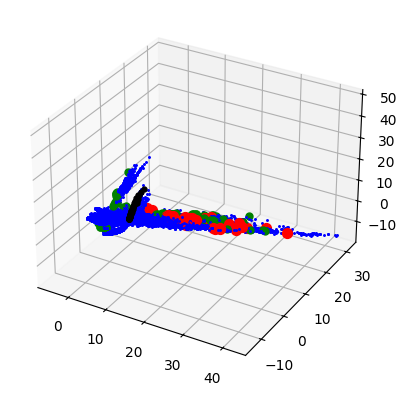

In [34]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
# np.shape(embeds[-1][0])
# e = embeds[-1][0]
# arr = []
counter = 0
for ee, qq, cc in zip(emb, arrqual, arrcol):
    counter += 1
    # for id, (e, o, q) in enumerate(zip(ee, oo, qq)):
        # pdb.set_trace()
    if cc=='k':
        color = 'k'
        # print(id, o[0:4])
        sz = 50
    elif cc=='r':
        color = 'r'
        sz = 200
    elif cc=='g':
        color = 'g'
        sz = 100
    else:
        color = 'b'
        sz = 5
    # print(e)
    # break
    # arr.append([ee[0], ee[1], ee[2], color, sz])
    ax.scatter(ee[0], ee[1], ee[2], marker='.', c=color, s=sz)
    if counter == 20000:
        break
plt.show()

In [ ]:
folder_graph = './RS/single_graph_things/finished_some_train/'
device = "cpu"

folder_graph_test = './RS/single_graph_things/finished_some_test/'
files_train = os.listdir(folder_graph_train)
files_train = [file for file in files_train if file.endswith('.pickle')]
files = os.listdir(folder_graph)
files = [file for file in files if file.endswith('.pickle') and (file not in files_train) and file.startswith('(')] #and (file not in files_test)

for file in files[:-1]:

    



In [2]:
import torch
from torch import nn
import torch_geometric
from torch_geometric.nn import GATConv, SAGEConv, GraphConv, GraphSAGE, GCNConv, GATv2Conv
import torch
import networkx as nx 
from torch.utils.data import Dataset
import pickle
import pdb 
import numpy as np
from torch_geometric.data import Data
import networkx as nx
import numpy as np
import pandas as pd 
import pickle
import pdb
from torch_geometric.loader import DataLoader
import torch.optim as optim
import torch.nn.functional as F
from torch_geometric.utils import to_dense_adj, subgraph, k_hop_subgraph
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.join(os.path.dirname(sys.path[0]),'tools'))
from sklearn.neighbors import kneighbors_graph
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch_geometric.data import Data
# from newGraphDat import GraphDataset
from GraphDatAll import GraphDataset
from sklearn.manifold import TSNE
import matplotlib as mpl
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
# import numpy as np
import scipy.io
# from graphDat import GraphDataset
# from ClassGraphDat import GraphDataset

torch.manual_seed(42)
 
# def visualize(h, data, title = "Scaatter Plot"):
#     colorlist = ['#e41a1c', '#984ea3', '#377eb8', '#4daf4a', '#ff7f00', '#ffff33', '#a65628']
#     z = TSNE(n_components=2).fit_transform(h.detach().cpu().numpy())

#     plt.figure(figsize=(10,10))
#     plt.xticks([])
#     plt.yticks([])
#     # alpha = [0.1 if G.nodes[node]["num_trajectories"] < LOWER_CONFIDENCE else 0.8 for node in G.nodes]
    


#     for class_number in range(data):
#         index_list = extract_nodes_by_class(data.y,class_number)
#         #a = [alpha[i] for i in index_list]
#         #plt.scatter(z[index_list, 0], z[index_list, 1], s=10, c=colorlist[class_number], alpha = a)
#         plt.scatter(z[index_list, 0], z[index_list, 1], s=10, c=colorlist[class_number], alpha = 0.7)

#     #plt.scatter(z[:, 0], z[:, 1], s=70, c=color, cmap="Set2")
#     _ = plt.legend(bin_dict.values(),bbox_to_anchor=(1, 1), loc='upper left')
#     plt.title(title)
#     plt.show()

# def extract_nodes_by_class(data,class_number):
#     index_list = []
#     for index, item in enumerate(data):
#         if data[index] == class_number:
#             index_list.append(index)
#     return index_list

# class Encoder(torch.nn.Module):
#     def __init__(self, dim_in, dim_h, dim_o, pr):
#         super().__init__()
#         self.hidden_layer_1 = GCNConv(dim_in, 4 * dim_h)
#         self.hidden_layer_2 = GCNConv(4 * dim_h, 2 * dim_h)
#         self.hidden_layer_3 = GCNConv(2 * dim_h, dim_h)
#         self.linear = nn.Linear(dim_h, dim_o)
#         self.shortcut = nn.Linear(dim_in, dim_o)
#         self.pr = pr
#     def forward(self, x, edge_index):
#         h_init = x
#         h = F.dropout(x, p=self.pr, training = self.training)
#         h = self.hidden_layer_1(h, edge_index)
#         h = F.elu(h)
#         h = F.dropout(h, p=self.pr, training = self.training)
#         h = self.hidden_layer_2(h, edge_index)
#         h = F.elu(h)
#         h = F.dropout(h, p=self.pr, training = self.training)
#         h = self.hidden_layer_3(h, edge_index)
#         h = self.linear(h)
#         h = h + self.shortcut(h_init)
#         return h


class GATNet(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, p):
        super(GATNet, self).__init__()
        # Define the first GAT convolution layer
        self.conv1 = GATConv(in_channels, hidden_channels*4, heads=8)#, dropout=0.3)
        # Define the second GAT convolution layer
        self.conv2 = GATConv(hidden_channels*4 * 8, hidden_channels*2, heads=8, concat=True)#, dropout=0.3)
        # Define the third GAT convolution layer
        self.conv3 = GATConv(hidden_channels*2 * 8, hidden_channels, heads=1, concat=True)#, dropout=0.3)
        # Define a linear layer to refine the outputs to the desired size
        self.linear = nn.Linear(hidden_channels, out_channels)
        self.shortcut = nn.Linear(in_channels, out_channels)
        self.p = p

    def forward(self, x, edge_index):
        init = x
        # x, edge_index = data.x, data.edge_index
        # Apply dropout to the input features and pass through the first GAT layer
        x = F.dropout(x, p=self.p, training=self.training)
        x = F.elu(self.conv1(x, edge_index))
        # Pass through the second GAT layer
        x = F.dropout(x, p=self.p, training=self.training)
        x = F.elu(self.conv2(x, edge_index))
        # Pass through the third GAT layer
        x = F.dropout(x, p=self.p, training=self.training)
        x = F.elu(self.conv3(x, edge_index))
        # Apply the linear layer
        x = self.linear(x)
        x = x + self.shortcut(init)
        return x
    
def cosine_loss(adj, emb, ew):
    # pdb.set_trace()
    norms = torch.norm(emb, p=2, dim=1, keepdim=True)
    normalized_embeddings = emb / norms.clamp(min=1e-4)
    cosine_similarity_matrix = torch.mm(normalized_embeddings, normalized_embeddings.t())
    target_adjacency = torch.zeros_like(cosine_similarity_matrix)
    normalized_weights = ew / torch.norm(ew, p=2, keepdim=True)
    target_adjacency[adj[0], adj[1]] = normalized_weights
    # Directly using logits; no need to apply sigmoid.
    return F.binary_cross_entropy_with_logits(cosine_similarity_matrix, target_adjacency)

# def train(model, dataloader, optimizer, device):#, timeclasses):
    
#     model.train()
#     total_loss = 0
#     embeddings = []
#     origs = []
#     qs = []
#     agents = []
#     printlosses = []
#     for feat, edge, _, _, q, nA, ts in dataloader:
#         optimizer.zero_grad()
#         features = feat.squeeze_(0).to(device)
#         edges = edge.squeeze_(0).to(device)
#         embed = model(features, edges)
        
#         qs.append(q)
#         agents.append(nA)

#         # time_classes = times.squeeze_(0).to(device)
#         # succ_classes = succ.squeeze_(0).to(device)
#         # time_succ_class = torch.cat([time_classes, succ_classes], axis=-1)
#         # pdb.set_trace()
#         loss = loss_function(embed, ts.squeeze_(0).to(device)) #cosine_loss(data[1][0].to(device), embed)
#         origs.append(ts.detach())
#         # loss = cosine_loss(embed, classes) 
#         # loss = focal_loss(embed, data[2][0].to(device)) #cosine_loss(data[1][0].to(device), embed)
#         loss.backward()
#         optimizer.step()
#         total_loss += loss.detach().item()
#         printlosses.append(loss.detach().item())
#         if len(printlosses)%1000 == 0:
#             printlosses = printlosses[-1000:]
#             print(np.sum(printlosses)/1000.0)
#         embeddings.append(embed.detach())
#         # print(total_loss)/10.0
#     return total_loss / len(dataloader), embeddings, origs, qs, agents

def train(model, data_loader, optimizer, device):
    model.train()
    total_loss = 0
    embeddings = []
    origs = []
    # qs = []
    # agents = []
    # printlosses = []
    for feat, edge, edge_weight, _, _, _, _, tS in dataloader:
        optimizer.zero_grad()
        # pdb.set_trace()
        # print(np.shape(feat), np.shape(edges))
        # print('in main: ', np.shape(feat), np.shape(edges))
        features = feat.squeeze_(0).to(device)
        # globalInfo = glob.squeeze_(0).to(device)
        edges = edge.squeeze_(0).to(device)
        ew = edge_weight.squeeze_(0).to(device)
        # embed = model(torch.cat([globalInfo, features], dim=1), edges)
        origs.append(tS)
        # print(np.shape(embed), np.shape(data[2][0]))
        # print()
        # print(data[2][0][0], embed[0].detach())
        # loss = lossfunc(embed, data[2][0].to(device))
        # print(np.shape(embed), np.shape(data[2][0]), np.shape(data[0][0]), np.shape(data[1][0]))
        # loss = loss_function(embed, data[2][0].to(device)) #cosine_loss(data[1][0].to(device), embed)
        embed = model(features, edges)
        loss = cosine_loss(edges, embed, ew)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        embeddings.append(embed.detach())
        # print(total_loss)
    return total_loss / len(data_loader), embeddings, origs

# Copy code
def validate(model, data_loader, device):
    model.eval()
    total_loss = 0
    counter = 0 
    validation_embeddings = []
    # validation_classes = []
    qs = []
    agents = []
    origs = []
    with torch.no_grad():
        for feat, edge, ew, _, _, q, nA, ts in data_loader:
            counter += 1
            features = feat.squeeze_(0).to(device)
            edges = edge.squeeze_(0).to(device)
            embed = model(features, torch.empty((2,1), dtype=torch.int64))
            validation_embeddings.append(embed.detach())
            qs.append(q)
            agents.append(nA)
            origs.append(ts.detach())
            # if counter < 5:
            #     print(embed)
            loss = cosine_loss(edges, embed, ew)
            total_loss += loss.item()
    return total_loss / len(data_loader), validation_embeddings, origs, qs, agents



def get_color(node, quals, na):
    red = node_to_color_red(node, quals, na)
    green = node_to_color_green(node, quals, na)
    black = node_to_color_black(node)
    if red is True:
        return 'r'
    elif green is True:
        return 'g'
    elif black is True:
        return 'k'
    else:
        return 'b'

# def get_full_qual(q):
#     while len(q) < 4:
#         q.append(0.0)
#     return q

    

def get_complete_poses(a):
    arr = [[MAX_DIST]*2]*4
    for i in range(0,len(a)):
        # pdb.set_trace()
        arr[i] = list(a[i])
    # pdb.set_trace()
    return arr

def get_complete_quals(a):
    arr = [0]*4
    for i in range(0,len(a)):
        # pdb.set_trace()
        arr[i] = a[i]
    # pdb.set_trace()
    return arr

def get_complete_global(a):
    arr = [0]*4
    for i in range(0,len(a)):
        # pdb.set_trace()
        arr[i] = a[i]
    # pdb.set_trace()
    return arr

def node_to_color_black(node):
    if node[3] == 0.0:
        return True
    else:
        return False

def node_to_color_green(node, quals, nA):
    # pdb.set_trace()
    # nA = np.sum([1 for _ in node[0::4]])
    dancers = [(1, q) for a, q in zip(node[0::4], node[3::4]) if a == 0.0]
    qs = [0]*4
    # pdb.set_trace()
    for d in dancers:
        ii = quals.index(d[1])
        qs[ii] += 1

    if np.max(qs) > COMMIT_THRESHOLD*nA:
        id = np.argmax(qs)
        if quals[id] == np.max(quals):
            return True
        else:
            return False
    else:
        return False
    
def node_to_color_red(node, quals, nA):
    # pdb.set_trace()
    # nA = np.sum([1 for _ in node[0::4]])
    dancers = [(1, q) for a, q in zip(node[0::4], node[3::4]) if a == 0.0]
    qs = [0]*4
    # pdb.set_trace()
    for d in dancers:
        ii = quals.index(d[1])
        qs[ii] += 1

    if np.max(qs) > COMMIT_THRESHOLD*nA:
        id = np.argmax(qs)
        if quals[id] != np.max(quals):
            return True
        else:
            return False
    else:
        return False


if __name__ == '__main__':
    device = "cpu"

    inC = 40

    nW = 8

    # fname = 'small_graphs.pth'
    valfolder = './finished_val/'
    files_val= os.listdir(valfolder)
    files_val = [file for file in files_val if file.endswith('.pickle')]

    folder_graph = './finished_some_train/'
    files = os.listdir(folder_graph)
    files = [file for file in files if file.endswith('.pickle') and file.startswith('(')] #and (file not in files_test)

    dataset = GraphDataset(folder_graph, files)
    dataloader = DataLoader(dataset, batch_size=1, shuffle=True, num_workers=nW)

    dataset_test = GraphDataset(valfolder, files_val)
    dataloader_test = DataLoader(dataset_test, batch_size=1, shuffle=True, num_workers=nW)

    # train_loss_end = []
    # test_loss_end = []
    for hC in [8]:#[8, 16]: #[8, 64]:#[8, 16, 32, 64]:#[8, 16, 32, 64]:
        for drops in [0.6]:#[0.4, 0.6]: #[0.2, 0.4, 0.6, 0.8]:#[0.2, 0.4, 0.6, 0.8]:
            for lrate in [0.01]:#[0.001, 0.05, 0.005, 0.01]: #[0.01, 0.05, 0.001, 0.005]:
                for decays in [0.0]:#[0.01, 0.0]: #[0]: #[5e-5, 0]:#[5e-4, 5e-5, 5e-3, 0.0]:
                    

                    print('hidden count: ', hC, 'drops: ', drops, 'lr: ', lrate, 'decays: ', decays)

                    actuals = []
                    final_loss = []
                    embeddings = []
                    outchannels = 4
                    validation_loss = 100
                    model = GATNet(inC, hC, outchannels, drops).to(device)
                    optimizer = optim.AdamW(model.parameters(), lr=lrate, weight_decay=decays)
                    # scheduler = ReduceLROnPlateau(optimizer, 'min', factor=0.1, patience=3, verbose=True)
                    # losses = []
                    # embeds = []
                    # torch.autograd.set_detect_anomaly(True)
                    # acts = []
                    for epoch in range(1, 7):  # Number of epochs
                        # loss, embed, orig = train(model, dataloader, optimizer, device)
                        loss, embed, tsclass = train(model, dataloader, optimizer, device)
                        # embeds.append(embed)
                        # acts.append(orig)
                        # print(f'Epoch {epoch}, Loss: {loss:.4f}')
                        if epoch % 2 == 0:
                            # In your main training loop:
                            # total_loss / len(data_loader), validation_embeddings, origs, qs, agents
                            validation_loss, ve, TSve, qs, ags  = validate(model, dataloader_test, device)
                            # validation_loss, _, _, _, _  = validate(model, dataloader_test, device)
                            # print(f'Validation Loss: {validation_loss:.4f}')
                    print('end train and val loss: ', loss, validation_loss)



CLIST =  ["Slow/Failure", "Slow/Success", "Fast/Failure", "Fast/Success"]
X = []
y = []
for vv, tsts in zip(ve, TSve):
# pdb.set_trace()
    for v in vv:
        X.append(v.tolist())
    y+=tsts[0].tolist()     
# pdb.set_trace()
trainX = []
trainy = []
for vv, tsts in zip(embed, tsclass):
# pdb.set_trace()
    for v in vv:
        trainX.append(v.tolist())
    trainy+=tsts[0].tolist()           
                    
                    

hidden count:  8 drops:  0.6 lr:  0.01 decays:  0.0
end train and val loss:  0.7369620489559888 1.3061950647667662


In [3]:


CLIST =  ["Slow/Failure", "Slow/Success", "Fast/Failure", "Fast/Success"]
X = []
y = []
for vv, tsts in zip(ve, TSve):
# pdb.set_trace()
    for v in vv:
        X.append(v.tolist())
    y+=tsts[0].tolist()     
# pdb.set_trace()
trainX = []
trainy = []
for vv, tsts in zip(embed, tsclass):
# pdb.set_trace()
    for v in vv:
        trainX.append(v.tolist())
    trainy+=tsts[0].tolist()           





In [28]:
# np.sum([1 for t in trainy if t==3])
# #  
# print(466034.0/209817,466034.0/99507,466034.0/6957,466034.0/149753 )

2.2211450931049437 4.683429306480951 66.98778208998131 3.112017789293036


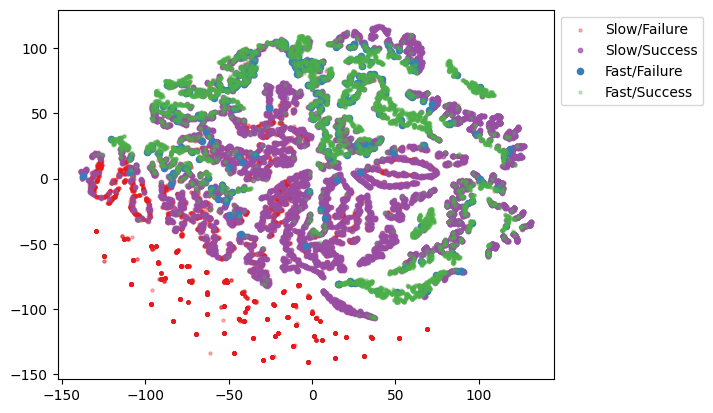

In [32]:
def extract_nodes_by_class(data,class_number):
    index_list = []
    # pdb.set_trace()
    for index, item in enumerate(data):
        if data[index] == class_number:
            index_list.append(index)
    return index_list

colorlist = ['#e41a1c', '#984ea3', '#377eb8', '#4daf4a', '#ff7f00', '#ffff33', '#a65628']
alphalist = [0.3, 0.7, 1.0, 0.3]
sizelist = [5, 10, 20, 5]
z = TSNE(n_components=2).fit_transform(np.array(X))

for class_number in range(4):
    index_list = extract_nodes_by_class(y,class_number)
    plt.scatter(z[index_list,0], z[index_list,1], s=sizelist[class_number], c=colorlist[class_number], alpha = alphalist[class_number])

plt.legend(CLIST,bbox_to_anchor=(1, 1), loc='upper left')

In [37]:



# np.save('trainX.npy', np.array(trainX))
# np.save('trainy.npy', np.array(trainy))
# np.save('X.npy', np.array(X))
# np.save('y.npy', np.array(y))

# # X = []
# est = GradientBoostingClassifier(n_estimators=300, max_depth=5) # n_estimators is the number of trees and max_depth is the maximum depth of any individual tree.
# est.fit(trainX,trainy)


In [36]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import  GridSearchCV
param_grid = {
    'n_estimators': [500, 1000],
    'learning_rate': [0.01, 0.1],
    'max_depth': [5, 6],
    # 'subsample': [0.8, 1.0],
    'min_samples_split': [2, 5, 10]
}
#    class_weight= {0: 2.2211450931049437, 1: 4.683429306480951, 2:66.98778208998131, 3:3.112017789293036}
# 0.45021822442139414 0.2135187561422557 0.014928095375015557 0.32133492406133457
gb = GradientBoostingClassifier()
grid_search = GridSearchCV(estimator=gb, param_grid=param_grid, cv=5, n_jobs=8, verbose=2)
grid_search.fit(trainX, trainy)
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X)

print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation score: {:.2f}".format(grid_search.best_score_))
print("Test set accuracy: {:.2f}".format(accuracy_score(y, y_pred)))
print("Classification report:\n", classification_report(y, y_pred))

Fitting 5 folds for each of 24 candidates, totalling 120 fits


KeyboardInterrupt: 

In [15]:

y_pred = est.predict(trainX)
cm = confusion_matrix(trainy, y_pred)#, labels = bin_dict.values())
# # CLIST =  bin_dict.values()


Text(0.5, 1.0, 'Confusion Matrix for 2-level GraphSage embedding')

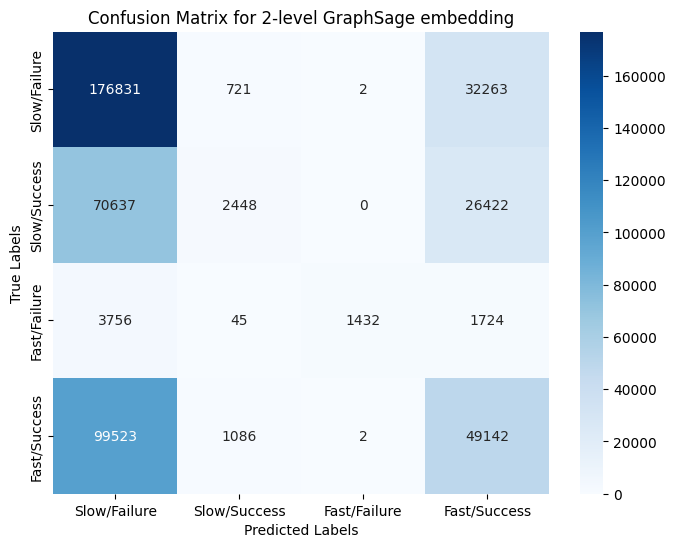

In [16]:

# np.save('cm.npy', np.array(cm))
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=CLIST, yticklabels=CLIST)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix for 2-level GraphSage embedding')

# arrdict = {'x':[], 'y':[], 'z':[], 'col':[], 'sz':[]}
# for i in cm:
#     # print(i)
#     # pdb.set_trace()
#     arrdict['x'].append(i[0])
#     arrdict['y'].append(i[1])
#     arrdict['z'].append(i[2])
#     arrdict['col'].append(i[3])
#     # arrdict['sz'].append(i[4])


# scipy.io.savemat('./CM.mat', arrdict)
# plt.savefig('somethingCM.pdf', bbox_inches='tight')
# plt.show() 